In [167]:
import numpy as np
from pykalman import KalmanFilter
from numba import njit


def sample_state_space_model(T=500):
    xs = np.zeros((2,T)) # Storage for latent states
    ys = np.zeros((T,)) # Storage for observations
    transition_matrix = np.array([[1, 0.8],[0, 0.1]])
    observation_matrix = np.array([1, 0])
    exogenous_vector = np.array([-1, 0])
    for i in range(1, T):
        xs[:,i] = transition_matrix @ xs[:,i-1] \
                  + exogenous_vector \
                  + np.random.multivariate_normal(np.zeros(2), np.eye(2))
        ys[i] = observation_matrix @ xs[:,i]
    return ys


# def log_likelihood(ys, theta, temp):
#     transition_matrix = np.array([[1, theta[0]],[0, 0.1]])
#     observation_matrix = np.array([1, 0])
#     transition_covariance = np.eye(2)
#     observation_covariance = np.array([temp])
#     transition_offset = np.array([theta[1], 0])
    
#     kf = KalmanFilter(
#         transition_matrices=transition_matrix,
#         observation_matrices=observation_matrix,
#         transition_covariance=transition_covariance,
#         observation_covariance=observation_covariance,
#         transition_offsets=transition_offset,
#         initial_state_mean=np.array([0.0, 0.0]),
#         initial_state_covariance=np.eye(2)
#     )
    
#     return kf.loglikelihood(ys)


def log_prior(theta):
    if -2.5 <= theta[0] <= 2.5:
        return 0.0
    else:
        return -np.inf


@njit
def log_likelihood(ys, theta, temp):
    a = theta[0]
    b = theta[1]

    # State mean and covariance
    m0, m1 = 0.0, 0.0
    P00, P01, P10, P11 = 1.0, 0.0, 0.0, 1.0

    ll = 0.0

    for t in range(len(ys)):
        # Prediction mean: A m + offset
        pm0 = m0 + a * m1 + b
        pm1 = 0.1 * m1

        # Prediction covariance: A P A' + I
        PP00 = P00 + a * P10 + a * P01 + a * a * P11 + 1.0
        PP01 = 0.1 * (P01 + a * P11)
        PP10 = 0.1 * (P10 + a * P11)
        PP11 = 0.01 * P11 + 1.0

        # Observation y = x0 + noise
        v = ys[t] - pm0
        S = PP00 + temp

        ll += -0.5 * (np.log(2.0 * np.pi) + np.log(S) + v * v / S)

        # Kalman gain
        K0 = PP00 / S
        K1 = PP10 / S

        # Update mean
        m0 = pm0 + K0 * v
        m1 = pm1 + K1 * v

        # Update covariance: (I - K H) P
        P00 = (1.0 - K0) * PP00
        P01 = (1.0 - K0) * PP01
        P10 = PP10 - K1 * PP00
        P11 = PP11 - K1 * PP01

    return ll


def metropolis_hastings(initial_theta, temp, n_iters=1, proposal_sd=0.01, print_log=True):
    if(print_log):
        print(f'Starting Metropolis-Hastings run\n \
                Parameters: \n \
                initial position = {initial_theta}\n \
                tempering        = {temp}\n \
                iterations       = {n_iters}\n \
                proposal_sd      = {proposal_sd}')
    samples = np.zeros((n_iters,2))
    samples[0,:] = initial_theta
    # Cache the log-likelihood so it doesn't have to be computed
    # twice each loop
    current_log_likelihood = log_likelihood(ys=ys,               \
                                            theta=initial_theta, \
                                            temp=temp)
    n_accepts = 0
    for i in range(1, n_iters):
        y = samples[i-1,:]
        # Random walk Metropolis-Hastings with multivariate normal proposal
        z = np.random.multivariate_normal(y, proposal_sd**2 * np.eye(2))
        d = np.random.uniform(low=0, high=1)
        new_log_likelihood = log_likelihood(ys=ys,   \
                                            theta=z, \
                                            temp=temp)
        # Compute acceptance probability in log scale to avoid underflow
        log_alpha = new_log_likelihood - current_log_likelihood
        if np.log(d) < min(log_alpha, 0):
            samples[i] = z
            current_log_likelihood = new_log_likelihood
            n_accepts += 1
        else:
            samples[i] = y
    if(print_log):
        print(f'Finished Metropolis-Hastings run \n \
                Acceptance rate: {n_accepts / n_iters}')
    return samples


temp = 10 # Initial tempering strength
n_particles = 1000 # Number of particles

# Sample an initial point from the prior, to be used as
# a starting point in Metropolis-Hastings sampling.
# Prior is uniform on [-2.5, 2.5] x [-2.5, 2.5].
initial_theta = np.random.uniform(low=-2.5, high=2.5, size=2)

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.
ys = sample_state_space_model(T=500) 

# Use random walk Metropolis-Hastings to sample initial parameter
# estimates.
thetas = metropolis_hastings(initial_theta=initial_theta,
                             temp=10,
                             n_iters=2000,
                             proposal_sd=0.1
                            )[-n_particles:]

Starting Metropolis-Hastings run
                 Parameters: 
                 initial position = [ 1.51231921 -0.25192307]
                 tempering        = 10
                 iterations       = 2000
                 proposal_sd      = 0.1
Finished Metropolis-Hastings run 
                 Acceptance rate: 0.434


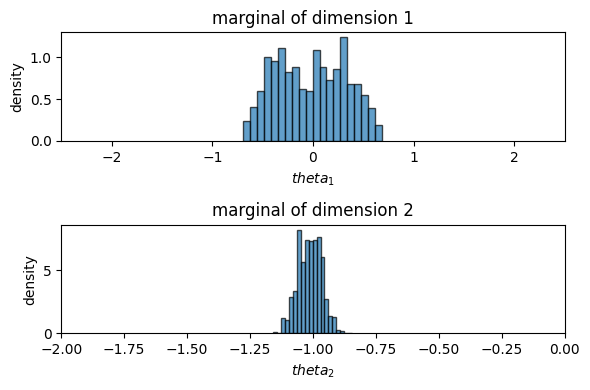

In [170]:
import matplotlib.pyplot as plt


x1 = thetas[:, 0]
x2 = thetas[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(6, 4))

axes[0].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title("marginal of dimension 1")
axes[0].set_xlabel("$theta_1$")
axes[0].set_ylabel("density")
axes[0].set_xlim(-2.5, 2.5)

axes[1].hist(x2, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title("marginal of dimension 2")
axes[1].set_xlabel("$theta_2$")
axes[1].set_ylabel("density")
axes[1].set_xlim(-2, 0)

plt.tight_layout()
plt.show()


In [ ]:
def ess(cur_omega, nxt_omega):
    n = len(cur_omega)
    assert n == len(nxt_omega)
    w = [cur_omega[j] / nxt_omega[j] for j in range(n)]
    s = sum(w)
    return 1 / sum([(w[j] / s)**2 for j in range(n)])


temp = 10 # Initial tempering strength
n_particles = 1000 # Number of particles

# Sample an initial point from the prior, to be used as
# a starting point in Metropolis-Hastings sampling.
# Prior is uniform on [-2.5, 2.5] x [-2.5, 2.5].
initial_theta = np.random.uniform(low=-2.5, high=2.5, size=2)

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.
ys = sample_state_space_model(T=500) 

# Use random walk Metropolis-Hastings to sample initial parameter
# estimates.
thetas = metropolis_hastings(initial_theta=initial_theta,
                             temp=10,
                             n_iters=2000,
                             proposal_sd=0.1
                            )[-n_particles:]

p = 0
while temp > 0.01:
    p += 1
    log_w = [ log_likelihood(ys=ys,theta=thetas[j,:],temp=temp) \
            + log_prior(thetas[j,:]) \
                for j in range(n_particles)]
    # Now comes a rather complicated bisection method thing
    # We need to find a value for temp such that
    # ESS(current posterior(old temp), next posterior(new temp)) = 0.5 * n_particles
    

Starting Metropolis-Hastings run
                 Parameters: 
                 initial position = [-1.96048757 -1.19127915]
                 tempering        = 10
                 iterations       = 2000
                 proposal_sd      = 0.1
Finished Metropolis-Hastings run 
                 Acceptance rate: 0.4695


KeyboardInterrupt: 